In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('..'))
import torch

from mounirood.tester import PonderationTester
from mounirood.datasets import get_y
from mounirood.framework import FrameworkFactory
from mounirood.modality_fusion import calc_perturbations, CoefficientPonderator
from mounirood.eval_functions import auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
from sklearn import metrics

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

# Delta MSP

In [ ]:
# Récupérer les datasets
framework = FrameworkFactory("near_ood")
dataset_id, dataset_ood = framework.get_confs("id", "react")["UCF"], framework.get_confs("ood","react")["UCF"]

# Faire un truc avec les confs
vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)
# Avoir des scores à la fin

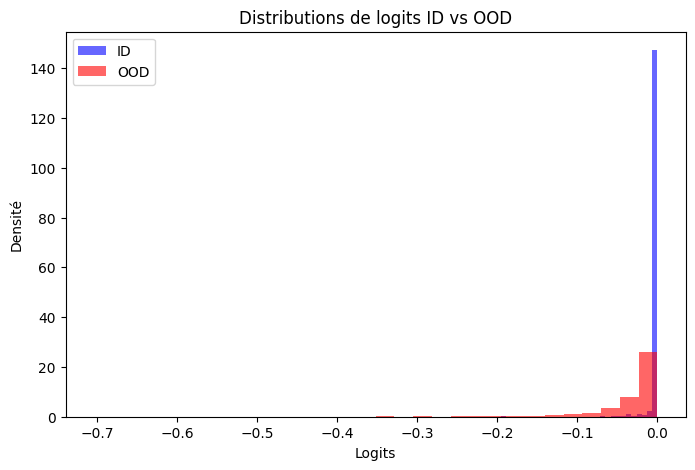

In [ ]:
scores = np.vstack((scores_id, scores_ood))
labels = get_y(dataset_id, dataset_ood)
auroc, _, _, fpr = auc_and_fpr_recall(scores, labels, tpr_th=0.95)
print("AUC ROC: {}\nFPR@TPR95: {}\n".format(auroc.round(4), fpr.round(4)))

separabilite({"logits_id_test":scores_id, "logits_ood_test": scores_ood})

# densité

In [ ]:
framework = FrameworkFactory("near_ood")
dataset_id, dataset_ood = framework.get_confs("id", "react")["UCF"], framework.get_confs("ood","react")["UCF"]

vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)

AUC ROC: 0.9417
FPR@TPR95: 0.2951



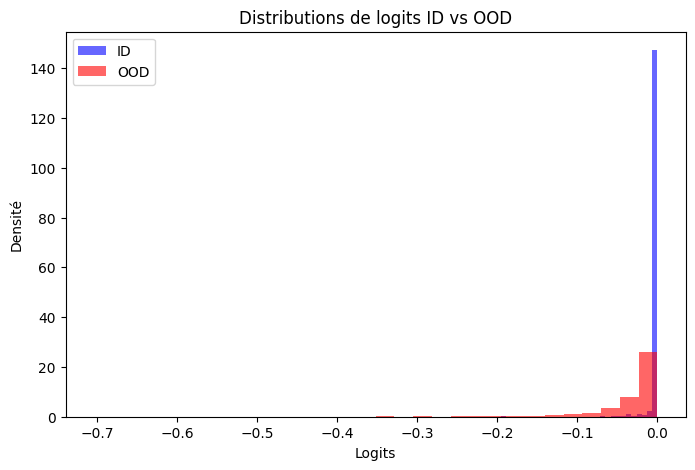

In [ ]:
scores = np.vstack((scores_id, scores_ood))
labels = get_y(dataset_id, dataset_ood)
auroc, _, _, fpr = auc_and_fpr_recall(scores, labels, tpr_th=0.95)
print("AUC ROC: {}\nFPR@TPR95: {}\n".format(auroc.round(4), fpr.round(4)))

separabilite({"logits_id_test":scores_id, "logits_ood_test": scores_ood})

## fit

In [7]:
with open("../_classifieur/classif_react/data_near.pkl", "rb") as f:
    data_all = pickle.load(f)
data = data_all["UCF"]
dataset_id = data["X_train"][data["y_train"].reshape(-1) == 0]
dataset_ood = data["X_train"][data["y_train"].reshape(-1) == 1]

In [13]:
vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)

In [4]:
from sklearn.mixture import GaussianMixture
from mounirood.eval_functions import calc_acc

In [6]:

# Empile les scores pour former un vecteur colonne
X_id = scores_id # shape: (N_id, 1)
X_ood = scores_ood  # shape: (N_ood, 1)

# Fit une gaussienne sur les ID et les OOD
gmm_id = GaussianMixture(n_components=1).fit(X_id)
gmm_ood = GaussianMixture(n_components=1).fit(X_ood)

# Score de log-vraisemblance pour une nouvelle donnée x
def log_likelihood(x):
    return gmm_ood.score_samples([[x]])[0] - gmm_id.score_samples([[x]])[0]

def pred(log_likelihood):
    return int(log_likelihood>1)

test

In [15]:
dataset_test = data["X_test"]
vecteur_sans_test = dataset_test[:, 0] 
confs_modalites_test = dataset_test[:, 2:]
perturbations_test = np.array([-calc_perturbations(vecteur_sans_test, vecteur_avec_test, method="diff_vector_abs") for vecteur_avec_test in confs_modalites_test.transpose()]).transpose()
scores_test = np.sum(perturbations_test, axis=1).reshape(-1)
preds = [pred(log_likelihood(x)) for x in scores_test]

In [11]:
from mounirood.eval_functions import calc_acc

In [ ]:
calc_acc(preds, data["y_test"]) #Sans valeur abs

0.46035969257354736

In [ ]:
calc_acc(preds, data["y_test"]) # Avec valeur abs

0.4627476632595062

loop sur tous les datasets

In [ ]:
accs = {}
for framework_name, file in list({"far_ood":"data_vf.pkl", "near_ood":"data_near.pkl", "vfa":"data_vfa.pkl"}.items()):
    for layer_proc in ["ash", "react"]:
        with open(f"../_classifieur/classif_{layer_proc}/{file}", "rb") as f:
            data_all = pickle.load(f)

        
        for dataset_name in ["HMDB", "UCF", "EPIC"]:
            if framework_name == "near_ood":
                data = data_all[dataset_name]
            else:
                data = data_all
                
            dataset_id = data["X_train"][data["y_train"].reshape(-1) == 0]
            dataset_ood = data["X_train"][data["y_train"].reshape(-1) == 1]
            vecteur_sans_id = dataset_id[:, 0] 
            confs_modalites_id = dataset_id[:, 2:]
            # delta_msp
            perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
            # shape : [N_modalités,]

            vecteur_sans_ood = dataset_ood[:, 0] 
            confs_modalites_ood = dataset_ood[:, 2:]
            # delta_msp
            perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
            # shape : [N_modalités,]

            # delta_msp_id = np.sum(perturbations_id)
            # delta_msp_ood = np.sum(perturbations_ood)
            scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
            scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)

            # Fit une gaussienne sur les ID et les OOD
            gmm_id = GaussianMixture(n_components=1).fit(scores_id)
            gmm_ood = GaussianMixture(n_components=1).fit(scores_ood)


            dataset_test = data["X_test"]
            vecteur_sans_test = dataset_test[:, 0] 
            confs_modalites_test = dataset_test[:, 2:]
            perturbations_test = np.array([-calc_perturbations(vecteur_sans_test, vecteur_avec_test, method="diff_vector_abs") for vecteur_avec_test in confs_modalites_test.transpose()]).transpose()
            scores_test = np.sum(perturbations_test, axis=1).reshape(-1)
            preds = [pred(log_likelihood(x)) for x in scores_test]
            
            if framework_name == "near_ood":
                accs[framework_name+"_"+dataset_name+"_"+layer_proc] = (calc_acc(preds, data["y_test"]))
            else:
                accs[framework_name+"_"+layer_proc] = (calc_acc(preds, data["y_test"]))
                break
        # print(np.mean(list(accs.values())))
print(accs)

{'far_ood_ash': 0.6133381724357605, 'far_ood_react': 0.8160586953163147, 'near_ood_HMDB_ash': 0.43358296155929565, 'near_ood_UCF_ash': 0.5620872378349304, 'near_ood_EPIC_ash': 0.3047606647014618, 'near_ood_HMDB_react': 0.26080581545829773, 'near_ood_UCF_react': 0.4627476632595062, 'near_ood_EPIC_react': 0.28763440251350403, 'vfa_ash': 0.3047606647014618, 'vfa_react': 0.28763440251350403}


In [ ]:
# mixture de gaussiennes avec valeur absolue
d = {'far_ood_ash': 0.6133381724357605, 'far_ood_react': 0.8160586953163147, 'near_ood_HMDB_ash': 0.43358296155929565, 'near_ood_UCF_ash': 0.5620872378349304, 'near_ood_EPIC_ash': 0.3047606647014618, 'near_ood_HMDB_react': 0.26080581545829773, 'near_ood_UCF_react': 0.4627476632595062, 'near_ood_EPIC_react': 0.28763440251350403, 'vfa_ash': 0.3047606647014618, 'vfa_react': 0.28763440251350403}
for k, v in d.items():
    print(k, v*100)

far_ood_ash 61.33381724357605
far_ood_react 81.60586953163147
near_ood_HMDB_ash 43.358296155929565
near_ood_UCF_ash 56.20872378349304
near_ood_EPIC_ash 30.47606647014618
near_ood_HMDB_react 26.080581545829773
near_ood_UCF_react 46.27476632595062
near_ood_EPIC_react 28.763440251350403
vfa_ash 30.47606647014618
vfa_react 28.763440251350403


In [ ]:
# mixture de gaussiennes sans valeur absolue
d = {'far_ood_ash': 0.5783406496047974, 'far_ood_react': 0.7859769463539124, 'near_ood_HMDB_ash': 0.3583413064479828, 'near_ood_UCF_ash': 0.5085967183113098, 'near_ood_EPIC_ash': 0.3093276619911194, 'near_ood_HMDB_react': 0.25987690687179565, 'near_ood_UCF_react': 0.46035969257354736, 'near_ood_EPIC_react': 0.28763440251350403, 'vfa_ash': 0.3093276619911194, 'vfa_react': 0.28763440251350403}
for k, v in d.items():
    print(k, v*100)

far_ood_ash 57.834064960479736
far_ood_react 78.59769463539124
near_ood_HMDB_ash 35.83413064479828
near_ood_UCF_ash 50.85967183113098
near_ood_EPIC_ash 30.93276619911194
near_ood_HMDB_react 25.987690687179565
near_ood_UCF_react 46.035969257354736
near_ood_EPIC_react 28.763440251350403
vfa_ash 30.93276619911194
vfa_react 28.763440251350403


In [ ]:
with open("../_classifieur/classif_react/data_vf.pkl", "rb") as f:
    data = pickle.load(f)

dataset_id = data["X_train"][data["y_train"].reshape(-1) == 0]
dataset_ood = data["X_train"][data["y_train"].reshape(-1) == 1]
vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)


# Empile les scores pour former un vecteur colonne
X_id = scores_id # shape: (N_id, 1)
X_ood = scores_ood  # shape: (N_ood, 1)

# Fit une gaussienne sur les ID et les OOD
gmm_id = GaussianMixture(n_components=1).fit(X_id)
gmm_ood = GaussianMixture(n_components=1).fit(X_ood)


dataset_test = data["X_test"]
vecteur_sans_test = dataset_test[:, 0] 
confs_modalites_test = dataset_test[:, 2:]
perturbations_test = np.array([-calc_perturbations(vecteur_sans_test, vecteur_avec_test, method="diff_vector") for vecteur_avec_test in confs_modalites_test.transpose()]).transpose()
scores_test = np.sum(perturbations_test, axis=1).reshape(-1)
preds = [pred(log_likelihood(x)) for x in scores_test]

accs[dataset_name] = (calc_acc(preds, data["y_test"]))
print(np.mean(list(accs.values())))

0.46539887514981354


In [8]:
with open("../_classifieur/classif_react/data_vf.pkl", "rb") as f:
    data = pickle.load(f)

dataset_id = data["X_train"][data["y_train"].reshape(-1) == 0]
dataset_ood = data["X_train"][data["y_train"].reshape(-1) == 1]
vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([-calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([-calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1).reshape(-1,1)
scores_ood = np.sum(perturbations_ood, axis=1).reshape(-1,1)


# Empile les scores pour former un vecteur colonne
X_id = scores_id # shape: (N_id, 1)
X_ood = scores_ood  # shape: (N_ood, 1)

# Fit une gaussienne sur les ID et les OOD
gmm_id = GaussianMixture(n_components=1).fit(X_id)
gmm_ood = GaussianMixture(n_components=1).fit(X_ood)


dataset_test = data["X_test"]
vecteur_sans_test = dataset_test[:, 0] 
confs_modalites_test = dataset_test[:, 2:]
perturbations_test = np.array([-calc_perturbations(vecteur_sans_test, vecteur_avec_test, method="diff_vector") for vecteur_avec_test in confs_modalites_test.transpose()]).transpose()
scores_test = np.sum(perturbations_test, axis=1).reshape(-1)
preds = [pred(log_likelihood(x)) for x in scores_test]

accs = (calc_acc(preds, data["y_test"]))
print(accs)

0.7859769463539124


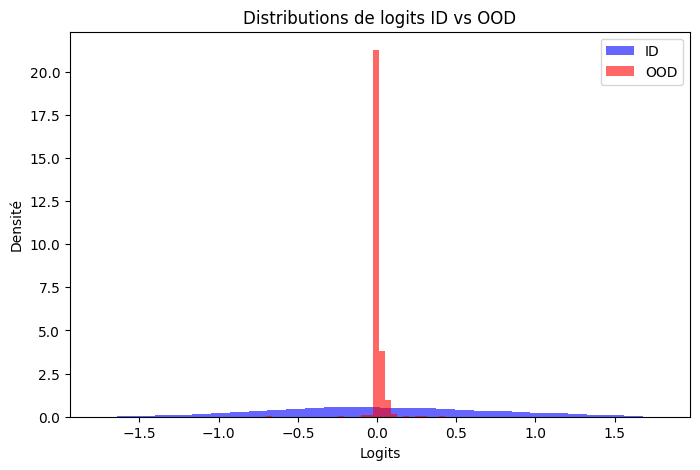

In [9]:
separabilite({"logits_id_test":scores_id, "logits_ood_test": scores_ood})

- si on visualise en meme temps le score react, peut etre que ca rajoute un parametre qui permettra de completement discriminer les deux distributions
- Peut-être que dans nos données il y a un autre paramètre qui permettra de shifter par exemple une des distributions. 
- Peut-être que ça ce n'est qu'une dimension d'un problème qui en a plus (auquel cas le fait qu'une distribution soit étalée et l'autre non ne change pas grand chose)

## Visualiser les MSP par modalité

In [ ]:
framework = FrameworkFactory("far_ood")
dataset_id, dataset_ood = framework.get_confs("id", "react"), framework.get_confs("ood", 'react')

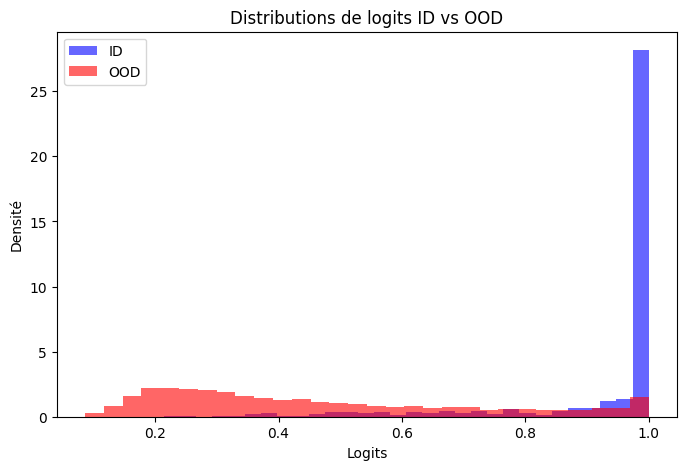

In [ ]:
scores_id = dataset_id[:,1]
scores_ood = dataset_ood[:,1]
separabilite({"logits_id_test":scores_id, "logits_ood_test": scores_ood})

construction de la dimension des deltas/perturbations

In [6]:
len(scores_id.shape) == len(scores_ood.shape)

True

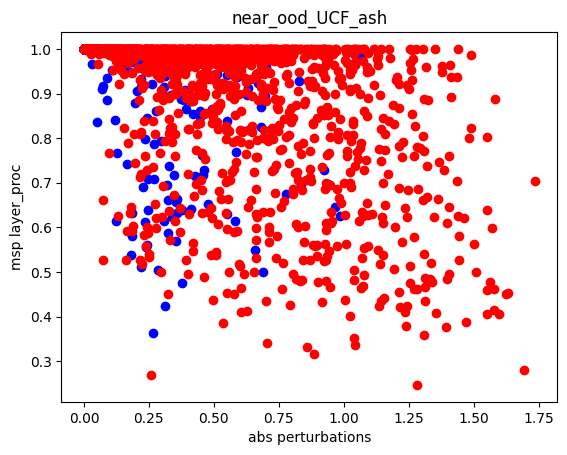

In [3]:
framework = FrameworkFactory("far_ood")
dataset_name = "UCF"
layer_proc = "ash"
dataset_id, dataset_ood = framework.get_confs("id", layer_proc), framework.get_confs("ood", layer_proc, dataset_name)

vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1)
scores_ood = np.sum(perturbations_ood, axis=1)

# Représenter les données par leur delta et le msp react
representation_id = np.hstack((scores_id.reshape(-1,1), dataset_id[:,1].reshape(-1,1)))
representation_ood = np.hstack((scores_ood.reshape(-1,1), dataset_ood[:,1].reshape(-1,1)))

plt.scatter(representation_id[:,0], representation_id[:,1], color="blue")
plt.scatter(representation_ood[:,0], representation_ood[:,1], color="red")
plt.xlabel("abs perturbations")
plt.ylabel("msp layer_proc")
plt.title("near_ood_UCF_ash")
plt.show()

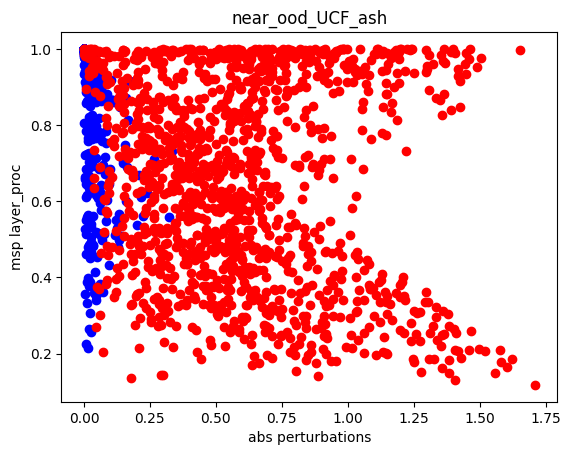

In [ ]:
framework = FrameworkFactory("far_ood")
dataset_name = "UCF"
layer_proc = "react"
dataset_id, dataset_ood = framework.get_confs("id", layer_proc), framework.get_confs("ood", layer_proc, dataset_name)

vecteur_sans_id = dataset_id[:, 0] 
confs_modalites_id = dataset_id[:, 2:]
# delta_msp
perturbations_id = np.array([calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_id.transpose()]).transpose()
# shape : [N_modalités,]

vecteur_sans_ood = dataset_ood[:, 0] 
confs_modalites_ood = dataset_ood[:, 2:]
# delta_msp
perturbations_ood = np.array([calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") for vecteur_avec in confs_modalites_ood.transpose()]).transpose()
# shape : [N_modalités,]

# delta_msp_id = np.sum(perturbations_id)
# delta_msp_ood = np.sum(perturbations_ood)
scores_id = np.sum(perturbations_id, axis=1)
scores_ood = np.sum(perturbations_ood, axis=1)

# Représenter les données par leur delta et le msp react
representation_id = np.hstack((scores_id.reshape(-1,1), dataset_id[:,1].reshape(-1,1)))
representation_ood = np.hstack((scores_ood.reshape(-1,1), dataset_ood[:,1].reshape(-1,1)))

plt.scatter(representation_id[:,0], representation_id[:,1], color="blue")
plt.scatter(representation_ood[:,0], representation_ood[:,1], color="red")
plt.xlabel("abs perturbations")
plt.ylabel("msp layer_proc")
plt.title("near_ood_UCF_ash")
plt.show()

AssertionError: Nom du dataset incorrect

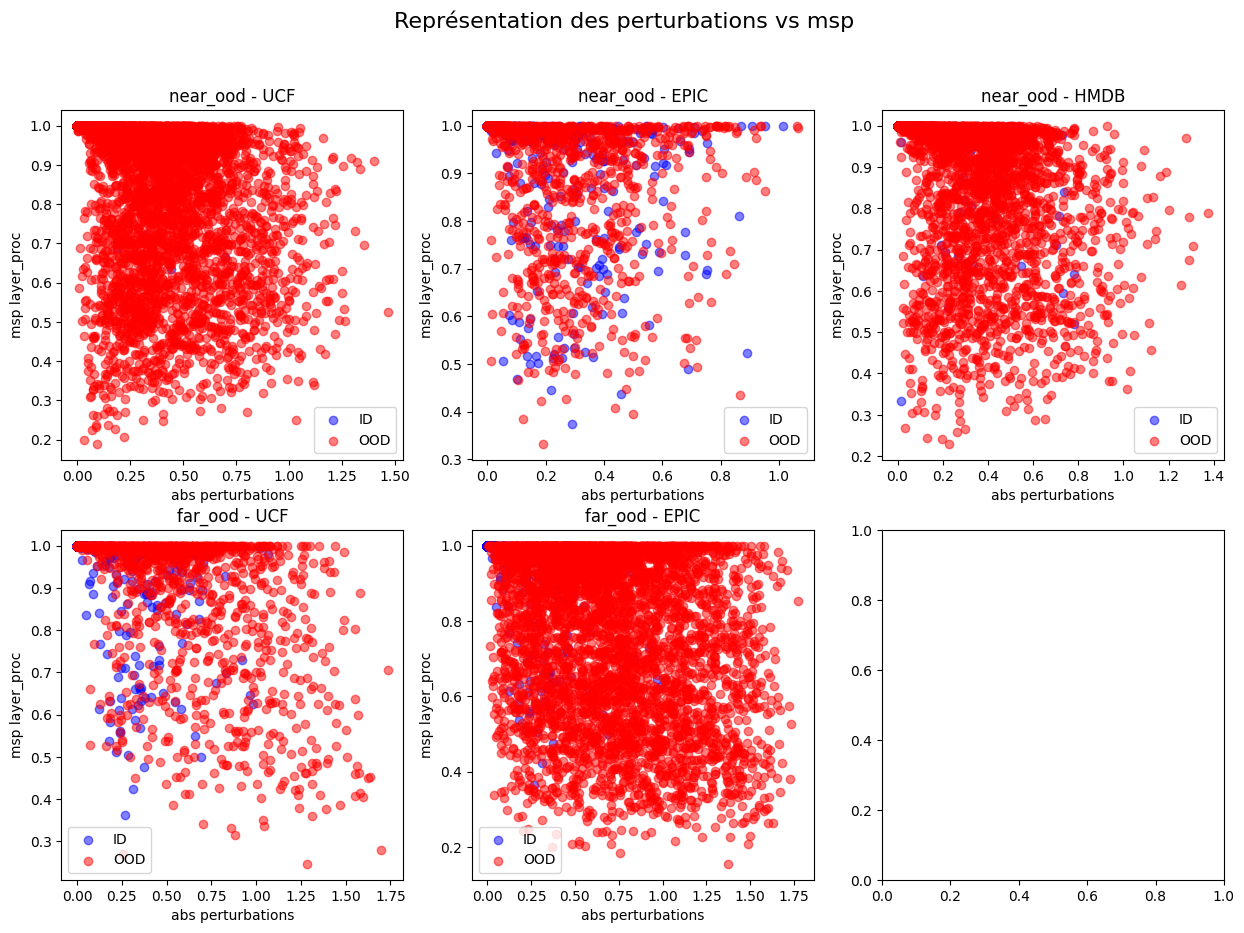

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows (near_ood, far_ood) x 3 datasets
fig.suptitle("Représentation des perturbations vs msp", fontsize=16)

for i, framework_name in enumerate(["near_ood", "far_ood"]):
    framework = FrameworkFactory(framework_name)
    
    for j, dataset_name in enumerate(["UCF", "EPIC", "HMDB"]):
        layer_proc = "ash"
        if framework_name == "far_ood":
            dataset_id = framework.get_confs("id", layer_proc)
        else:
            dataset_id = framework.get_confs("id", layer_proc, dataset_name)
        dataset_ood = framework.get_confs("ood", layer_proc, dataset_name)

        vecteur_sans_id = dataset_id[:, 0] 
        confs_modalites_id = dataset_id[:, 2:]
        perturbations_id = np.array([
            calc_perturbations(vecteur_sans_id, vecteur_avec, method="diff_vector_abs") 
            for vecteur_avec in confs_modalites_id.transpose()
        ]).transpose()

        vecteur_sans_ood = dataset_ood[:, 0] 
        confs_modalites_ood = dataset_ood[:, 2:]
        perturbations_ood = np.array([
            calc_perturbations(vecteur_sans_ood, vecteur_avec, method="diff_vector_abs") 
            for vecteur_avec in confs_modalites_ood.transpose()
        ]).transpose()

        scores_id = np.sum(perturbations_id, axis=1)
        scores_ood = np.sum(perturbations_ood, axis=1)

        representation_id = np.hstack((scores_id.reshape(-1, 1), dataset_id[:, 1].reshape(-1, 1)))
        representation_ood = np.hstack((scores_ood.reshape(-1, 1), dataset_ood[:, 1].reshape(-1, 1)))

        ax = axs[i, j]
        ax.scatter(representation_id[:, 0], representation_id[:, 1], color="blue", alpha=0.5, label="ID")
        ax.scatter(representation_ood[:, 0], representation_ood[:, 1], color="red", alpha=0.5, label="OOD")
        ax.set_title(f"{framework_name} - {dataset_name}")
        ax.set_xlabel("abs perturbations")
        ax.set_ylabel("msp layer_proc")
        ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for the main title
plt.show()
